Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
(Remove corrupted / invalid images)
        ↓
Train / Validation / Test Split
        ↓
Image Transformations
        ↓
Create Dataset
(ImageFolder)
        ↓
Create DataLoaders
        ↓
Visualize Images
        ↓
Baseline CNN
(Custom CNN Architecture)
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
(Optional)
        ↓
Model Evaluation
        ↓
        ┌──────────────────────────────┐
        │      Improve Performance     │
        └──────────────┬───────────────┘
                       ↓
               Transfer Learning
                       ↓
          Choose Pretrained Model
      (ResNet / EfficientNet / MobileNet)
                       ↓
             Modify Classifier
                       ↓
             Freeze / Unfreeze Layers
                       ↓
              Fine-Tuning
                       ↓
              Model Evaluation
                       ↓
             Compare Models
          Custom CNN vs Pretrained
                       ↓
               Select Best Model
                       ↓
              Save Trained Model
                       ↓
             Inference / Prediction
                       ↓
              Deployment (Streamlit)
                       ↓
                GitHub + README

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

In [2]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
CUDA Available: True
Using Device: cuda
GPU: Tesla T4


<mark>**Project Goal :**

The goal of this project is to build a deep learning image classification system using CNNs (Convolutional Neural Networks) and Transfer Learning that can analyze images of Indian food and classify them into different food categories.

The project will demonstrate how computer vision and deep learning can be used to learn visual patterns from food images and perform automated food classification. A pretrained EfficientNet model will be used with transfer learning and fine-tuning to improve the classification performance.

In [4]:
#next step: Data Collection

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Shipsense', '"I am restarting my study journey after a 6.5-yea....gsheet', 'Google AI Studio', 'chest_xray_model_bht.pth', 'chest_xray_checkpoint_bht.pth', 'class_to_idx_bht.json', 'chest_xray_model_best.pth', 'new_chest_xray_model_bht.pth', 'new_chest_xray_checkpoint_bht.pth', 'new_class_to_idx_bht.json', 'Indian Food Images', 'indian_food_model_baseline.pth', 'indian_food_checkpoint_baseline.pth', 'indian_food_class_to_idx.json']


In [6]:
dataset_path = r"/content/drive/MyDrive/Indian Food Images"

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))


#lets print all classes

for i in range(len(classes)):
  print(f"{i}. {classes[i]}")


Number of classes: 5
0. biryani
1. butter_chicken
2. gulab_jamun
3. naan
4. palak_paneer


#dataset understanding

In this step, we will analyze the structure and characteristics of the
Indian Food Images dataset before performing data cleaning and splitting.

We will inspect:

- Number of images in each class
- Total number of images
- Image dimensions
- Image channels
- File formats
- Sample images
- Class distribution

In [7]:
#no. of images in each class

class_counts = {}

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

biryani: 50
butter_chicken: 50
gulab_jamun: 50
naan: 50
palak_paneer: 50


In [ ]:
#total number of images

total_images = sum(class_counts.values())
print("Total images:", total_images)

Total images: 250


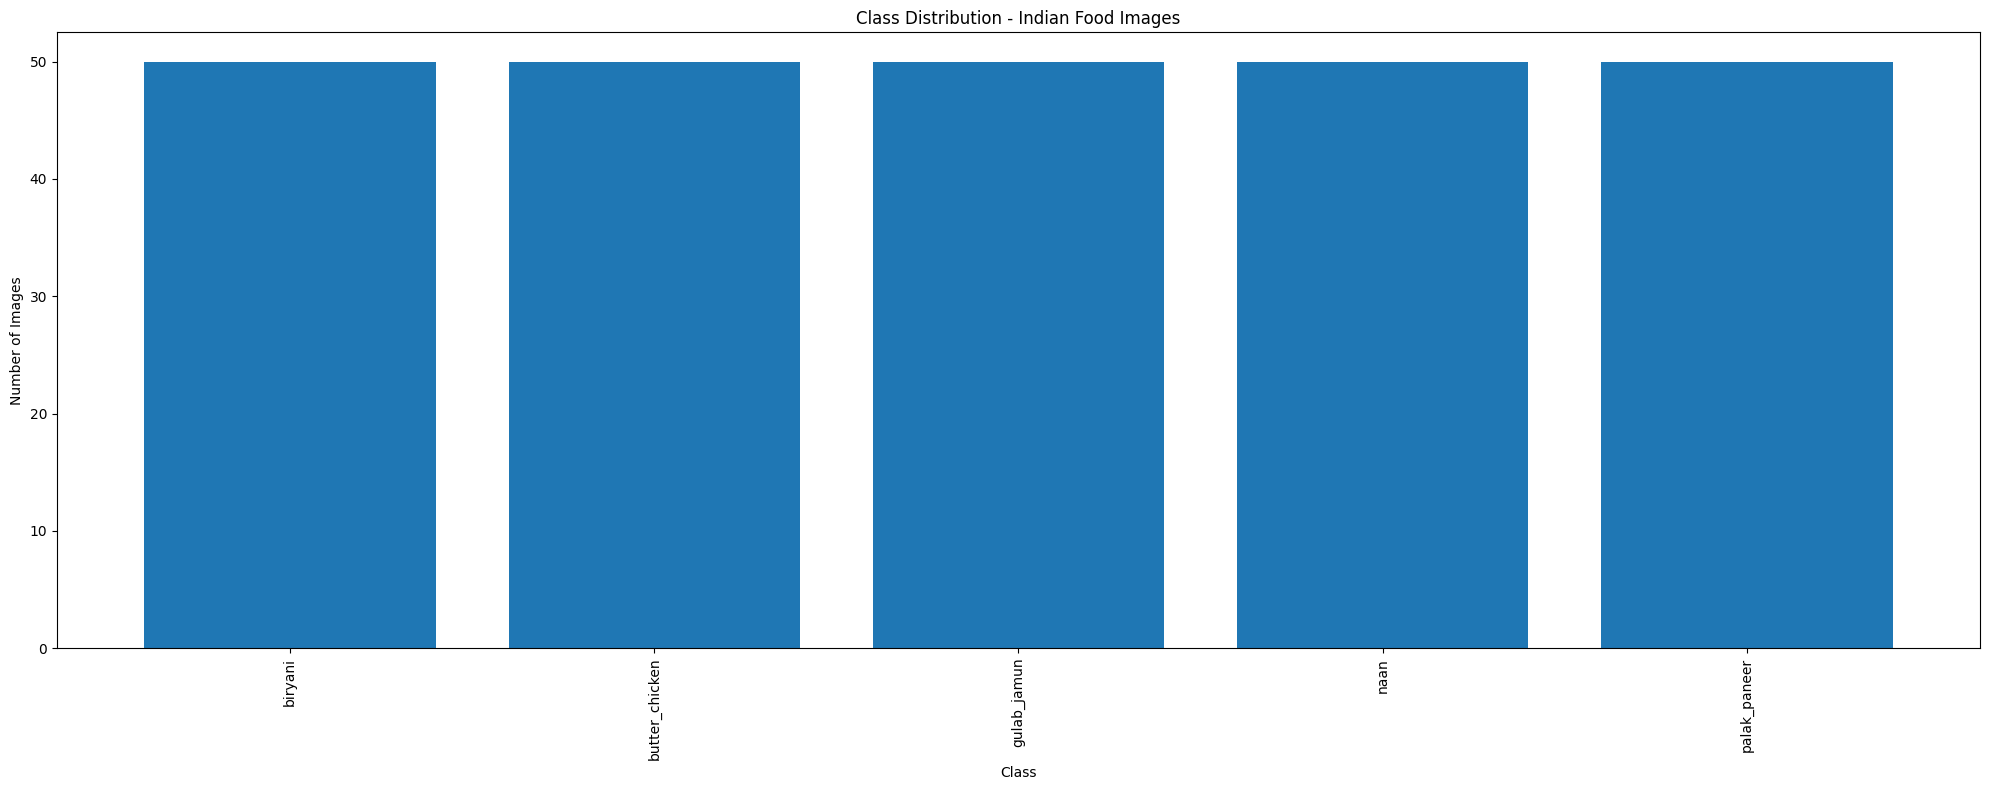

In [ ]:
#class distribution

plt.figure(figsize=(20, 8))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution - Indian Food Images")
plt.tight_layout()

plt.savefig("/content/class_distribution.png", dpi=400, bbox_inches="tight")



plt.show()

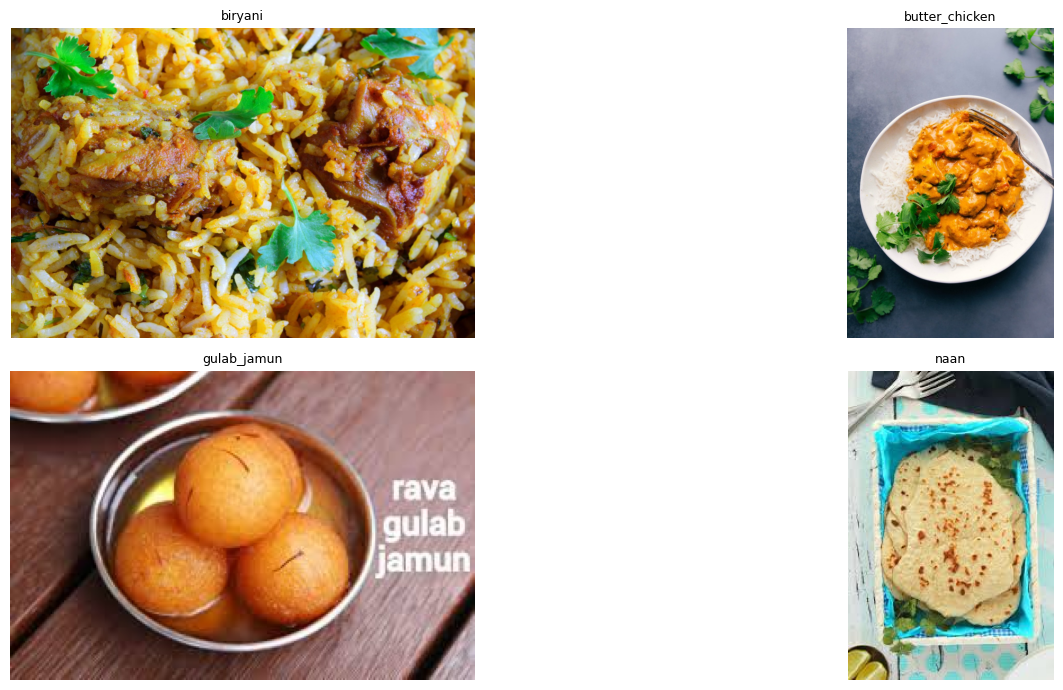

In [ ]:
# visualize a few sample images

fig, axes = plt.subplots(2, 2, figsize=(18, 7))
sample_classes = classes[:10]

for ax, cls in zip(axes.flatten(), sample_classes):

    cls_path = os.path.join(dataset_path, cls)

    files = os.listdir(cls_path)

    # skip empty folders
    if len(files) == 0:
        ax.set_title(f"{cls}\n(Empty Folder)", fontsize=9)
        ax.axis("off")
        continue

    sample_file = files[0]

    img = Image.open(os.path.join(cls_path, sample_file))

    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis("off")

plt.tight_layout()

plt.savefig("/content/final_visualizing_sample_images.png", dpi=400, bbox_inches="tight")

plt.show()

#data cleaning

Scan every image in the dataset and remove any file that is corrupted
or cannot be opened as a valid image, before splitting the data.

In [ ]:
#scan for corrupted / invalid images

corrupted_files = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except (UnidentifiedImageError, OSError):
            corrupted_files.append(fpath)

print("Corrupted images found:", len(corrupted_files))
print(corrupted_files)

Corrupted images found: 0
[]


In [ ]:
#remove corrupted images

for fpath in corrupted_files:
    os.remove(fpath)

print("Removed", len(corrupted_files), "corrupted images")

Removed 0 corrupted images


#train / validation / test split

Split ratio: 70% Train, 15% Validation, 15% Test.
Split is done on indices of the full ImageFolder dataset (random, seeded for reproducibility).

In [13]:
#image transformations

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [14]:
#create dataset using ImageFolder and split into train/val/test

full_dataset_train_tf = datasets.ImageFolder(root=dataset_path, transform=train_transform)
full_dataset_eval_tf = datasets.ImageFolder(root=dataset_path, transform=eval_transform)

num_samples = len(full_dataset_train_tf)

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_size = int(train_ratio * num_samples)
val_size = int(val_ratio * num_samples)
test_size = num_samples - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(num_samples, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(full_dataset_train_tf, train_indices)
val_dataset = Subset(full_dataset_eval_tf, val_indices)
test_dataset = Subset(full_dataset_eval_tf, test_indices)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 175
Validation: 37
Test: 38


In [15]:
#class to index mapping

class_to_idx = full_dataset_train_tf.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Number of classes:", len(class_to_idx))

Number of classes: 5


#create dataloaders

In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 6
Validation batches: 2
Test batches: 2


#visualize images from a training batch

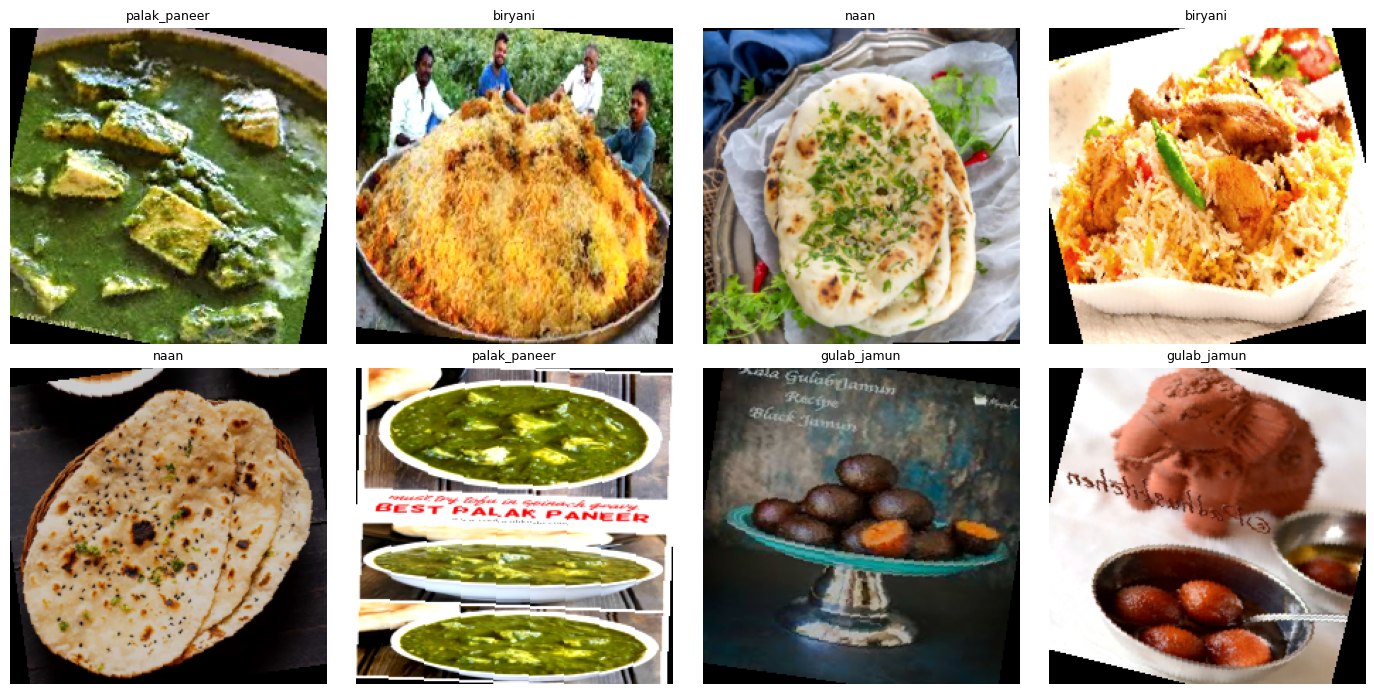

In [17]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, img, label in zip(axes.flatten(), images[:8], labels[:8]):
    img = denormalize(img).permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(img)
    ax.set_title(idx_to_class[label.item()], fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

#baseline CNN (custom architecture)

In [18]:
class FoodCNN(nn.Module):
    def __init__(self, num_classes):
        super(FoodCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#loss function and optimizer

In [19]:
num_classes = len(class_to_idx)

model = FoodCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


#training loop

In [ ]:
num_epochs = 15

train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

Epoch [1/15] Loss: 0.9741
Epoch [2/15] Loss: 0.9846
Epoch [3/15] Loss: 0.8994
Epoch [4/15] Loss: 0.8060
Epoch [5/15] Loss: 0.8849
Epoch [6/15] Loss: 0.7418
Epoch [7/15] Loss: 0.6154
Epoch [8/15] Loss: 0.4841
Epoch [9/15] Loss: 0.5814
Epoch [10/15] Loss: 0.5493
Epoch [11/15] Loss: 0.4127
Epoch [12/15] Loss: 0.3931
Epoch [13/15] Loss: 0.3402
Epoch [14/15] Loss: 0.3010
Epoch [15/15] Loss: 0.4220


#validation

In [ ]:
model.eval()

running_val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_loss = running_val_loss / len(val_loader)
val_accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Loss: 0.6936
Validation Accuracy: 81.08%


#model evaluation (on test set)

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 63.16%


In [ ]:
from sklearn.metrics import classification_report

target_names = [idx_to_class[i] for i in range(num_classes)]

print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))

                precision    recall  f1-score   support

       biryani       0.67      0.36      0.47        11
butter_chicken       0.44      0.70      0.54        10
   gulab_jamun       0.88      0.70      0.78        10
          naan       0.33      0.50      0.40         2
  palak_paneer       1.00      1.00      1.00         5

      accuracy                           0.63        38
     macro avg       0.66      0.65      0.64        38
  weighted avg       0.69      0.63      0.64        38



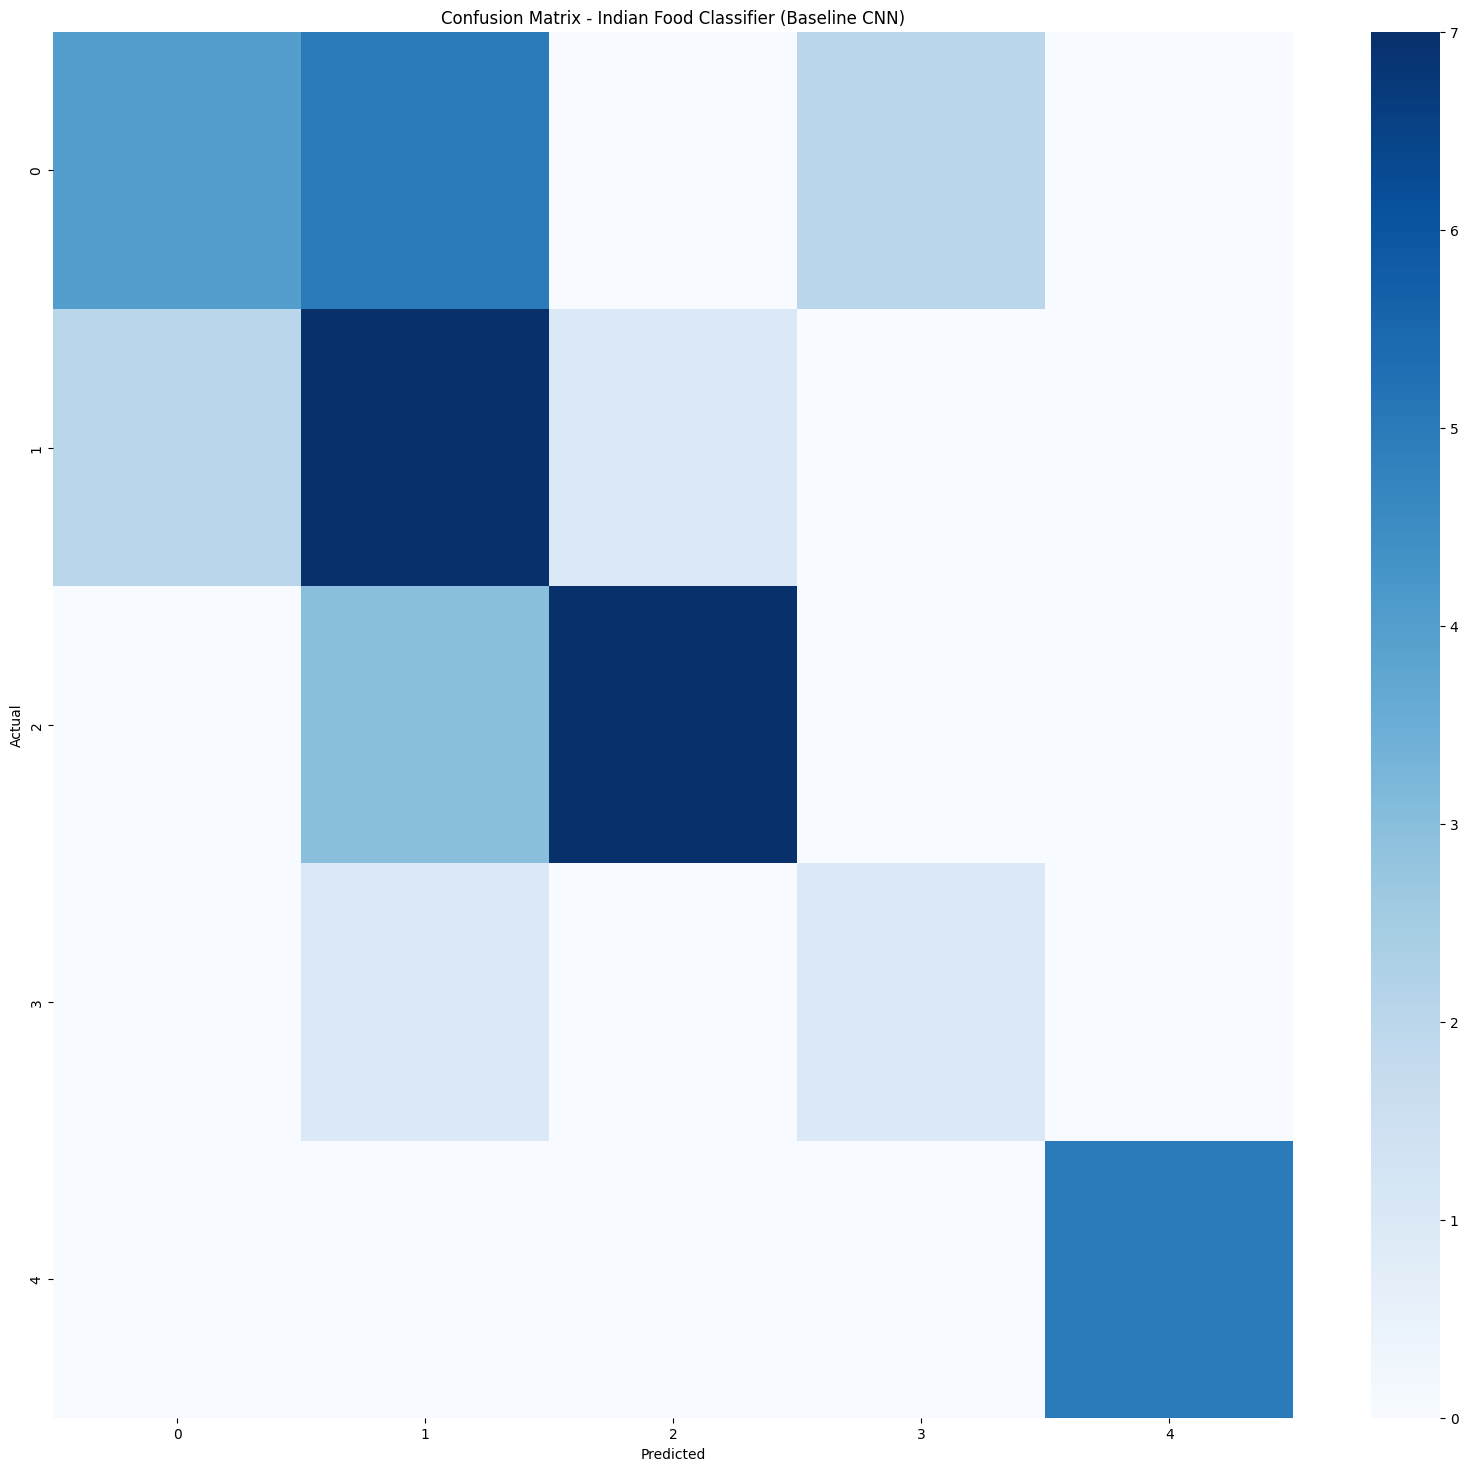

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Indian Food Classifier (Baseline CNN)")
plt.show()

#save trained model (baseline, before hyperparameter tuning / transfer learning)

In [ ]:
save_dir = "/content/drive/MyDrive"

# 1. Model weights only
torch.save(model.state_dict(), f"{save_dir}/indian_food_model_baseline.pth")

# 2. Full checkpoint (for resuming training later if needed)
torch.save({
    "epoch": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": epoch_loss,
}, f"{save_dir}/indian_food_checkpoint_baseline.pth")

# 3. Class-to-index mapping
with open(f"{save_dir}/indian_food_class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f)

print("Saved: indian_food_model_baseline.pth, indian_food_checkpoint_baseline.pth, indian_food_class_to_idx.json")

Saved: indian_food_model_baseline.pth, indian_food_checkpoint_baseline.pth, indian_food_class_to_idx.json


# Transfer Learning with EfficientNet

In this stage, a pretrained EfficientNet model will be used to improve
the classification performance of the Indian Food Image Classifier.

The pretrained model will be adapted for five Indian food categories.

In [8]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torch.nn as nn

In [10]:
#now lets import efficientnet

weights = EfficientNet_B0_Weights.DEFAULT

efficientnet = models.efficientnet_b0(weights=weights)

efficientnet

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
for param in efficientnet.parameters():
    param.requires_grad = False

In [20]:
class_to_idx

{'biryani': 0,
 'butter_chicken': 1,
 'gulab_jamun': 2,
 'naan': 3,
 'palak_paneer': 4}

In [21]:
num_classes = len(class_to_idx)

in_features = efficientnet.classifier[1].in_features

efficientnet.classifier[1] = nn.Linear(
    in_features,
    num_classes
)

efficientnet = efficientnet.to(device)

In [22]:
#loss and optimiser

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    efficientnet.classifier[1].parameters(),
    lr=0.001
)

In [23]:
efficientnet.classifier[1].parameters()

<generator object Module.parameters at 0x792182d0a420>

In [24]:
num_epochs = 10

efficientnet_train_losses = []

for epoch in range(num_epochs):

    efficientnet.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = efficientnet(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    efficientnet_train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10] Loss: 1.5706
Epoch [2/10] Loss: 1.3022
Epoch [3/10] Loss: 1.1155
Epoch [4/10] Loss: 0.9637
Epoch [5/10] Loss: 0.8016
Epoch [6/10] Loss: 0.7431
Epoch [7/10] Loss: 0.6119
Epoch [8/10] Loss: 0.5309
Epoch [9/10] Loss: 0.5087
Epoch [10/10] Loss: 0.4684


In [25]:
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

efficientnet_test_accuracy = (
    100 *
    sum(p == l for p, l in zip(all_preds, all_labels))
    / len(all_labels)
)

print(
    f"EfficientNet Test Accuracy: "
    f"{efficientnet_test_accuracy:.2f}%"
)

EfficientNet Test Accuracy: 84.21%


In [26]:
from sklearn.metrics import classification_report

target_names = [
    idx_to_class[i]
    for i in range(num_classes)
]

print("\nClassification Report - EfficientNet-B0")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=target_names,
        zero_division=0
    )
)


Classification Report - EfficientNet-B0
                precision    recall  f1-score   support

       biryani       0.83      0.91      0.87        11
butter_chicken       1.00      0.50      0.67        10
   gulab_jamun       0.83      1.00      0.91        10
          naan       1.00      1.00      1.00         2
  palak_paneer       0.71      1.00      0.83         5

      accuracy                           0.84        38
     macro avg       0.88      0.88      0.86        38
  weighted avg       0.87      0.84      0.83        38



In [28]:
import os
import json
import torch

# ============================================================
# SAVE EFFICIENTNET-B0
# ============================================================

save_dir = "/content/drive/MyDrive/Indian_Food_EfficientNet"
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# 1. Save final model
# ------------------------------------------------------------

final_model_path = os.path.join(
    save_dir,
    "efficientnet_b0_final.pth"
)

torch.save(
    efficientnet.state_dict(),
    final_model_path
)

print("✓ Final model saved")


# ------------------------------------------------------------
# 2. Save best model
# ------------------------------------------------------------

best_model_path = os.path.join(
    save_dir,
    "efficientnet_b0_best.pth"
)

if "best_model_state" in globals():
    torch.save(best_model_state, best_model_path)
    print("✓ Best model saved")
else:
    # Current model as fallback
    torch.save(efficientnet.state_dict(), best_model_path)
    print("✓ Best model saved (current model)")


# ------------------------------------------------------------
# 3. Get class mapping
# ------------------------------------------------------------

# train_dataset is a Subset, so access the original ImageFolder
base_dataset = train_dataset.dataset

class_to_idx = base_dataset.class_to_idx

class_mapping_path = os.path.join(
    save_dir,
    "class_to_idx.json"
)

with open(class_mapping_path, "w") as f:
    json.dump(class_to_idx, f, indent=4)

print("✓ Class mapping saved")


# ------------------------------------------------------------
# 4. Save metrics
# ------------------------------------------------------------

metrics = {
    "model": "EfficientNet-B0",
    "test_accuracy": 84.21,
    "test_samples": len(test_dataset),
    "num_classes": num_classes,
    "classes": list(class_to_idx.keys())
}

metrics_path = os.path.join(
    save_dir,
    "efficientnet_metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("✓ Metrics saved")


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EFFICIENTNET-B0 SAVED SUCCESSFULLY")
print("=" * 60)

print(f"\nFolder:")
print(save_dir)

print("\nFiles:")
print("✓ efficientnet_b0_final.pth")
print("✓ efficientnet_b0_best.pth")
print("✓ class_to_idx.json")
print("✓ efficientnet_metrics.json")

print("\nTest Accuracy: 84.21%")

✓ Final model saved
✓ Best model saved (current model)
✓ Class mapping saved
✓ Metrics saved

EFFICIENTNET-B0 SAVED SUCCESSFULLY

Folder:
/content/drive/MyDrive/Indian_Food_EfficientNet

Files:
✓ efficientnet_b0_final.pth
✓ efficientnet_b0_best.pth
✓ class_to_idx.json
✓ efficientnet_metrics.json

Test Accuracy: 84.21%
